## Preliminares

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import PowerTransformer
import sklearn.impute as skl_imp
from sklearn.experimental import enable_iterative_imputer # Necesario para usar skl_imp, no borrar
from src.config import data_folder
from src.funcionesTransform import *

In [2]:
# Abrir archivo raw_data
df = pd.read_parquet(f"{data_folder}/raw_data.parquet")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4486 entries, 0 to 4485
Data columns (total 26 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Date                    4486 non-null   datetime64[ns]
 1   Open                    4486 non-null   float64       
 2   Close                   4486 non-null   float64       
 3   Dividends               4486 non-null   float64       
 4   Ticker                  4486 non-null   object        
 5   Sector                  4486 non-null   object        
 6   DateAdded               4486 non-null   object        
 7   TotalRevenue            4486 non-null   float64       
 8   GrossProfit             4240 non-null   float64       
 9   OperatingIncome         4486 non-null   float64       
 10  NetIncome               4486 non-null   float64       
 11  EBITDA                  4486 non-null   float64       
 12  BasicAverageShares      4481 non-null   float64 

In [3]:
# Se convierten las variables de flujo trimestrales a valores TTM (ventana móvil de 4 trimestres)
df = transformar_flujos_a_ttm(df)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4486 entries, 0 to 4485
Data columns (total 26 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Date                    4486 non-null   datetime64[ns]
 1   Open                    4486 non-null   float64       
 2   Close                   4486 non-null   float64       
 3   Dividends               4486 non-null   float64       
 4   Ticker                  4486 non-null   object        
 5   Sector                  4486 non-null   object        
 6   DateAdded               4486 non-null   object        
 7   CashAndCashEquivalents  4479 non-null   float64       
 8   CurrentDebt             3625 non-null   float64       
 9   LongTermDebt            4298 non-null   float64       
 10  TotalDebt               3891 non-null   float64       
 11  StockholdersEquity      4480 non-null   float64       
 12  TotalAssets             4482 non-null   float64 

In [4]:
# Valores missing
df.apply(lambda x: x.isna().sum() / len(x)).sort_values(ascending=False)

GrossProfit_TTM           0.304503
CapitalExpenditure_TTM    0.248997
FreeCashFlow_TTM          0.244539
OperatingCashFlow_TTM     0.239412
FinancingCashFlow_TTM     0.238743
BasicAverageShares_TTM    0.238297
InvestingCashFlow_TTM     0.238074
TotalRevenue_TTM          0.237182
OperatingIncome_TTM       0.237182
NetIncome_TTM             0.237182
EBITDA_TTM                0.237182
CurrentDebt               0.191930
TotalDebt                 0.132635
LongTermDebt              0.041908
CashAndCashEquivalents    0.001560
StockholdersEquity        0.001337
TotalAssets               0.000892
CurrentLiabilities        0.000892
CurrentAssets             0.000892
DateAdded                 0.000000
Ticker                    0.000000
Dividends                 0.000000
Close                     0.000000
Open                      0.000000
Date                      0.000000
Sector                    0.000000
dtype: float64

In [5]:
# Se imputan parte de los NaNs en variables de Deuda antes de calcular métricas, 
# mediante las relaciones contables entre ellas.
df_debt_imputed = imputar_deuda(df)
df_debt_imputed.apply(lambda x: x.isna().sum() / len(x)).sort_values(ascending=False)

GrossProfit_TTM           0.304503
CapitalExpenditure_TTM    0.248997
FreeCashFlow_TTM          0.244539
OperatingCashFlow_TTM     0.239412
FinancingCashFlow_TTM     0.238743
BasicAverageShares_TTM    0.238297
InvestingCashFlow_TTM     0.238074
TotalRevenue_TTM          0.237182
OperatingIncome_TTM       0.237182
NetIncome_TTM             0.237182
EBITDA_TTM                0.237182
CurrentDebt               0.142220
TotalDebt                 0.132635
LongTermDebt              0.038564
CashAndCashEquivalents    0.001560
StockholdersEquity        0.001337
TotalAssets               0.000892
CurrentLiabilities        0.000892
CurrentAssets             0.000892
DateAdded                 0.000000
Ticker                    0.000000
Dividends                 0.000000
Close                     0.000000
Open                      0.000000
Date                      0.000000
Sector                    0.000000
dtype: float64

In [6]:
# Calcular métricas
df_with_metrics, crecimiento_cols = calcular_metricas(df_debt_imputed)
df_with_metrics.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4486 entries, 0 to 4485
Data columns (total 48 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Date                    4486 non-null   datetime64[ns]
 1   Open                    4486 non-null   float64       
 2   Close                   4486 non-null   float64       
 3   Dividends               4486 non-null   float64       
 4   Ticker                  4486 non-null   object        
 5   Sector                  4486 non-null   object        
 6   DateAdded               4486 non-null   object        
 7   CashAndCashEquivalents  4479 non-null   float64       
 8   CurrentDebt             3848 non-null   float64       
 9   LongTermDebt            4313 non-null   float64       
 10  TotalDebt               3891 non-null   float64       
 11  StockholdersEquity      4480 non-null   float64       
 12  TotalAssets             4482 non-null   float64 

In [7]:
# Se aplica imputación transversal para las columnas de crecimiento
df_with_metrics = imputar_transversal(df_with_metrics, crecimiento_cols)
df_with_metrics.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4486 entries, 0 to 4485
Data columns (total 48 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Date                    4486 non-null   datetime64[ns]
 1   Open                    4486 non-null   float64       
 2   Close                   4486 non-null   float64       
 3   Dividends               4486 non-null   float64       
 4   Ticker                  4486 non-null   object        
 5   Sector                  4486 non-null   object        
 6   DateAdded               4486 non-null   object        
 7   CashAndCashEquivalents  4479 non-null   float64       
 8   CurrentDebt             3848 non-null   float64       
 9   LongTermDebt            4313 non-null   float64       
 10  TotalDebt               3891 non-null   float64       
 11  StockholdersEquity      4480 non-null   float64       
 12  TotalAssets             4482 non-null   float64 

In [8]:
# Calcular los retornos trimestrales, varianza del activo y covarianza con el mercado para cada ticker
# Se abre el fichero de precios del Índice del Mercado
df_index = pd.read_parquet(f"{data_folder}/market_index.parquet")
df_with_features = calcular_retornos(df_with_metrics, df_index)
df_with_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4486 entries, 0 to 4485
Data columns (total 51 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Date                    4486 non-null   datetime64[ns]
 1   Open                    4486 non-null   float64       
 2   Close                   4486 non-null   float64       
 3   Dividends               4486 non-null   float64       
 4   Ticker                  4486 non-null   object        
 5   Sector                  4486 non-null   object        
 6   DateAdded               4486 non-null   object        
 7   CashAndCashEquivalents  4479 non-null   float64       
 8   CurrentDebt             3848 non-null   float64       
 9   LongTermDebt            4313 non-null   float64       
 10  TotalDebt               3891 non-null   float64       
 11  StockholdersEquity      4480 non-null   float64       
 12  TotalAssets             4482 non-null   float64 

## Missing Values

In [9]:
# Incidencia de missings en columnas numéricas
df_cont = df_with_features.select_dtypes(include='number')
df_cont.apply(lambda x: x.isna().sum() / len(x)).sort_values(ascending=False)

GrossProfit_TTM           0.304503
CapExToRevenue            0.248997
CapitalExpenditure_TTM    0.248997
FreeCashFlow_TTM          0.244539
FcfToEbitda               0.244539
OperatingCashFlow_TTM     0.239412
FinancingCashFlow_TTM     0.238743
MarketCap                 0.238297
BasicAverageShares_TTM    0.238297
PriceToBook               0.238297
EnterpriseToEbitda        0.238297
EnterpriseValue           0.238297
TrailingPE                0.238297
InvestingCashFlow_TTM     0.238074
NetDebtToEbitda           0.237851
ReturnOnAssets            0.237182
ReturnOnEquity            0.237182
ProfitMargins             0.237182
OperatingIncome_TTM       0.237182
TotalRevenue_TTM          0.237182
NetIncome_TTM             0.237182
OperatingMargins          0.237182
EBITDA_TTM                0.237182
QuarterlyReturn           0.169639
MarketCovariance          0.168301
QuarterlyVariance         0.168301
CurrentDebt               0.142220
TotalDebt                 0.132635
LongTermDebt        

In [10]:
# Incidencia de missings en columnas no numéricas
df_non_numeric = df_with_features.select_dtypes(exclude='number')
df_non_numeric.apply(lambda x: x.isna().sum() / len(x)).sort_values(ascending=False)

Date         0.0
Ticker       0.0
Sector       0.0
DateAdded    0.0
dtype: float64

In [11]:
# Comprobar valores infinitos antes de imputación multivariable
print(np.isinf(df_cont).sum())

Open                      0
Close                     0
Dividends                 0
CashAndCashEquivalents    0
CurrentDebt               0
LongTermDebt              0
TotalDebt                 0
StockholdersEquity        0
TotalAssets               0
CurrentAssets             0
CurrentLiabilities        0
TotalRevenue_TTM          0
GrossProfit_TTM           0
OperatingIncome_TTM       0
NetIncome_TTM             0
EBITDA_TTM                0
BasicAverageShares_TTM    0
OperatingCashFlow_TTM     0
InvestingCashFlow_TTM     0
FinancingCashFlow_TTM     0
FreeCashFlow_TTM          0
CapitalExpenditure_TTM    0
MarketCap                 0
EnterpriseValue           0
TrailingPE                0
EnterpriseToEbitda        0
PriceToBook               0
OperatingMargins          0
ProfitMargins             0
ReturnOnEquity            0
ReturnOnAssets            0
DebtToEquity              0
CurrentRatio              0
Revenue_YoY               0
Revenue_QoQ               0
Ebitda_YoY          

In [12]:
# NaN Restantes: Imputación multivariable con IterativeImputer sobre numéricas
# Imputador: Chain equations
imputer_itImp = skl_imp.IterativeImputer(max_iter=10, random_state=0)

df_cont_imputed = pd.DataFrame(imputer_itImp.fit_transform(df_cont),columns=df_cont.columns)
df_cont_imputed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4486 entries, 0 to 4485
Data columns (total 47 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Open                    4486 non-null   float64
 1   Close                   4486 non-null   float64
 2   Dividends               4486 non-null   float64
 3   CashAndCashEquivalents  4486 non-null   float64
 4   CurrentDebt             4486 non-null   float64
 5   LongTermDebt            4486 non-null   float64
 6   TotalDebt               4486 non-null   float64
 7   StockholdersEquity      4486 non-null   float64
 8   TotalAssets             4486 non-null   float64
 9   CurrentAssets           4486 non-null   float64
 10  CurrentLiabilities      4486 non-null   float64
 11  TotalRevenue_TTM        4486 non-null   float64
 12  GrossProfit_TTM         4486 non-null   float64
 13  OperatingIncome_TTM     4486 non-null   float64
 14  NetIncome_TTM           4486 non-null   

In [13]:
# Se vuelven a unir las columnas numéricas y no numéricas
df_imputed = pd.concat([df_cont_imputed, df_non_numeric], axis=1)
df_imputed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4486 entries, 0 to 4485
Data columns (total 51 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Open                    4486 non-null   float64       
 1   Close                   4486 non-null   float64       
 2   Dividends               4486 non-null   float64       
 3   CashAndCashEquivalents  4486 non-null   float64       
 4   CurrentDebt             4486 non-null   float64       
 5   LongTermDebt            4486 non-null   float64       
 6   TotalDebt               4486 non-null   float64       
 7   StockholdersEquity      4486 non-null   float64       
 8   TotalAssets             4486 non-null   float64       
 9   CurrentAssets           4486 non-null   float64       
 10  CurrentLiabilities      4486 non-null   float64       
 11  TotalRevenue_TTM        4486 non-null   float64       
 12  GrossProfit_TTM         4486 non-null   float64 

## Transformaciones

In [14]:
# Se calculan tamaños relativos: RelativeAssets y RelativeRevenue
df_transformed = calcular_relative_size(df_imputed)

In [15]:
# Se expresan columnas monetarias en billions
cols_financieras = obtener_cols_financieras()
cols_monetarias = cols_financieras + [
    'MarketCap', 
    'EnterpriseValue', 
    'TotalMarketAssets', 
    'TotalMarketRevenue'
    ]

for col in cols_monetarias:
    df_transformed[col] = df_transformed[col] / 10**9

In [16]:
#  Pasar DateAdded a formato datetime y transformar a YearsSinceAdded
df_transformed['DateAdded'] = pd.to_datetime(df_transformed['DateAdded'], errors='coerce')
df_transformed['YearsSinceAdded'] = round(((pd.Timestamp.now() - df_transformed['DateAdded']).dt.days / 365.25), 0)
df_transformed.drop('DateAdded', axis=1, inplace=True)

In [17]:
# Convertir Sector a category
df_transformed['Sector'] = df_transformed['Sector'].astype('category')

# Valores unicos en Sector
df_transformed['Sector'].value_counts()

Sector
InformationTechnology    847
Industrials              674
ConsumerDiscretionary    559
HealthCare               529
RealEstate               414
Financials               342
Materials                261
Utilities                257
CommunicationServices    222
Energy                   204
ConsumerStaples          177
Name: count, dtype: int64

In [18]:
# Distribución de variables contínuas
df_transformed.describe().round(4).T

,count,mean,min,25%,50%,75%,max,std
Open,4486.0,182.7539,7.8,58.7887,111.4119,213.2738,8027.5298,304.299
Close,4486.0,187.3043,7.84,59.7115,113.4288,219.0159,7517.79,300.8303
Dividends,4486.0,0.5344,0.0,0.0,0.28,0.7,90.0,1.95
CashAndCashEquivalents,4486.0,3.3423,-0.0017,0.4705,1.3424,3.6055,101.816,5.7193
CurrentDebt,4486.0,1.5474,-2.5167,0.1208,0.608,1.6135,90.814,4.0539
LongTermDebt,4486.0,13.6205,-0.1289,3.1208,7.6031,16.1842,144.231,17.7276
TotalDebt,4486.0,15.4132,-3.1443,3.4468,8.7311,17.5882,209.888,20.662
StockholdersEquity,4486.0,15.9625,-15.147,3.2251,8.1289,17.1754,478.746,29.8225
TotalAssets,4486.0,47.4733,1.1756,11.7816,25.2132,55.9264,916.63,65.6843
CurrentAssets,4486.0,13.0239,0.0192,2.4499,5.4371,14.091,265.527,23.4592


In [19]:
# Coeficientes de asimetría
df_transformed.select_dtypes(include="number").skew().sort_values(ascending=False)

CapExToRevenue            38.568668
Dividends                 35.483770
EnterpriseToEbitda        23.317101
Revenue_QoQ               17.948564
MarketCap                 17.138510
EnterpriseValue           16.929033
CurrentRatio              15.650876
QuarterlyVariance         14.401973
NetIncome_TTM             14.108852
Open                      13.365167
Revenue_YoY               12.932642
Close                     12.046957
CurrentDebt               11.919156
OperatingCashFlow_TTM     11.437070
EBITDA_TTM                11.217211
OperatingIncome_TTM       11.182062
RelativeAssets             9.700316
FreeCashFlow_TTM           8.812398
DebtToEquity               7.759754
RelativeRevenue            7.727790
GrossProfit_TTM            7.443736
BasicAverageShares_TTM     7.143341
StockholdersEquity         7.019659
Ebitda_YoY                 6.369094
ReturnOnEquity             5.879253
CurrentLiabilities         5.768848
TotalRevenue_TTM           5.692433
CashAndCashEquivalents     4

Cont


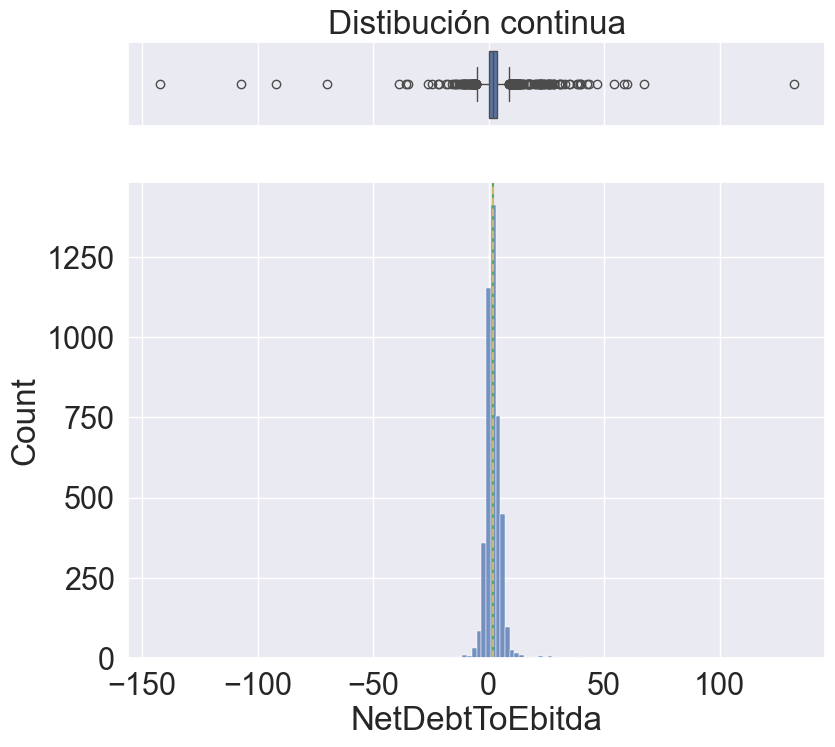

In [20]:
# Graficar
columna_a_graficar = 'NetDebtToEbitda' # indicar columna para el grafico
plot(df_transformed[columna_a_graficar])

In [21]:
# Transformaciones logarítmicas

columnas_a_transformar = [ 
    'CurrentRatio',
    'RelativeAssets',
    'RelativeRevenue'
    ]
for columna in columnas_a_transformar:
    df_transformed[columna] = df_transformed[columna].fillna(0)
    df_transformed[f'{columna}_log'] = np.log1p(df_transformed[columna])
    df_transformed.drop(columna, axis=1, inplace=True)

# Coeficientes de asimetria actualizado
df_transformed.select_dtypes(include="number").skew().sort_values(ascending=False)

CapExToRevenue            38.568668
Dividends                 35.483770
EnterpriseToEbitda        23.317101
Revenue_QoQ               17.948564
MarketCap                 17.138510
EnterpriseValue           16.929033
QuarterlyVariance         14.401973
NetIncome_TTM             14.108852
Open                      13.365167
Revenue_YoY               12.932642
Close                     12.046957
CurrentDebt               11.919156
OperatingCashFlow_TTM     11.437070
EBITDA_TTM                11.217211
OperatingIncome_TTM       11.182062
FreeCashFlow_TTM           8.812398
RelativeAssets_log         8.730262
DebtToEquity               7.759754
GrossProfit_TTM            7.443736
RelativeRevenue_log        7.157876
BasicAverageShares_TTM     7.143341
StockholdersEquity         7.019659
Ebitda_YoY                 6.369094
ReturnOnEquity             5.879253
CurrentLiabilities         5.768848
TotalRevenue_TTM           5.692433
CashAndCashEquivalents     4.983207
CurrentAssets              4

In [ ]:
# Definir columnas que saltean la "winsorización"
columnas_intactas = cols_monetarias + [
    # Variables de precio (posibles label)
    'Close',
    'Open',    
    'TrailingPE',
    'EnterpriseToEbitda',
    'PriceToBook',
    # Otras
    'Date', 
    'Ticker',
    'Dividends'        
    ]

# Separar el dataset
df_passthrough = df_transformed[columnas_intactas].copy()
df_transformed_features = df_transformed.drop(columns=columnas_intactas)

## Gestión de Outliers

Se winsorizan los valores atipicos en las variables continuas que cumplan los siguientes criterios:

Para variables simetricas:
* A mas de 3 desviaciones tipicas de la media.
* Mas de 3 rangos intercuartilicos.

Para variables asimetricas (modulo del coeficiente de asimetrica mayor a 1):
* A mas de 3 MADs de la mediana.
* Mas de 3 rangos intercuartilicos.

In [23]:
# Outliers
df_cont_transformed = df_transformed_features.select_dtypes(include="number")
df_winsor = df_cont_transformed.apply(lambda x: gestiona_outliers(x, clas='winsor'))

OperatingMargins
ProfitMargins
ReturnOnEquity
ReturnOnAssets
DebtToEquity
Revenue_YoY
Revenue_QoQ
Ebitda_YoY
Ebitda_QoQ
Fcf_YoY
Fcf_QoQ
CapEx_YoY
CapEx_QoQ
NetDebtToEbitda
FcfToEbitda
CapExToRevenue
QuarterlyReturn
QuarterlyVariance
MarketCovariance
YearsSinceAdded
CurrentRatio_log
RelativeAssets_log
RelativeRevenue_log


In [24]:
# Coeficientes de asimetria luego de winsorizar
df_winsor.skew().sort_values(ascending=False)

RelativeAssets_log     1.781850
QuarterlyVariance      1.743773
CapExToRevenue         1.730639
RelativeRevenue_log    1.657095
YearsSinceAdded        1.190108
CurrentRatio_log       1.007596
Revenue_QoQ            0.976368
Revenue_YoY            0.722701
ProfitMargins          0.683845
OperatingMargins       0.640423
QuarterlyReturn        0.582610
NetDebtToEbitda        0.485262
Ebitda_QoQ             0.440774
Ebitda_YoY             0.232796
Fcf_YoY                0.170772
Fcf_QoQ                0.087279
DebtToEquity           0.029725
MarketCovariance       0.027184
FcfToEbitda           -0.147891
ReturnOnEquity        -0.271032
ReturnOnAssets        -0.293843
CapEx_YoY             -0.510811
CapEx_QoQ             -0.782778
dtype: float64

Cont


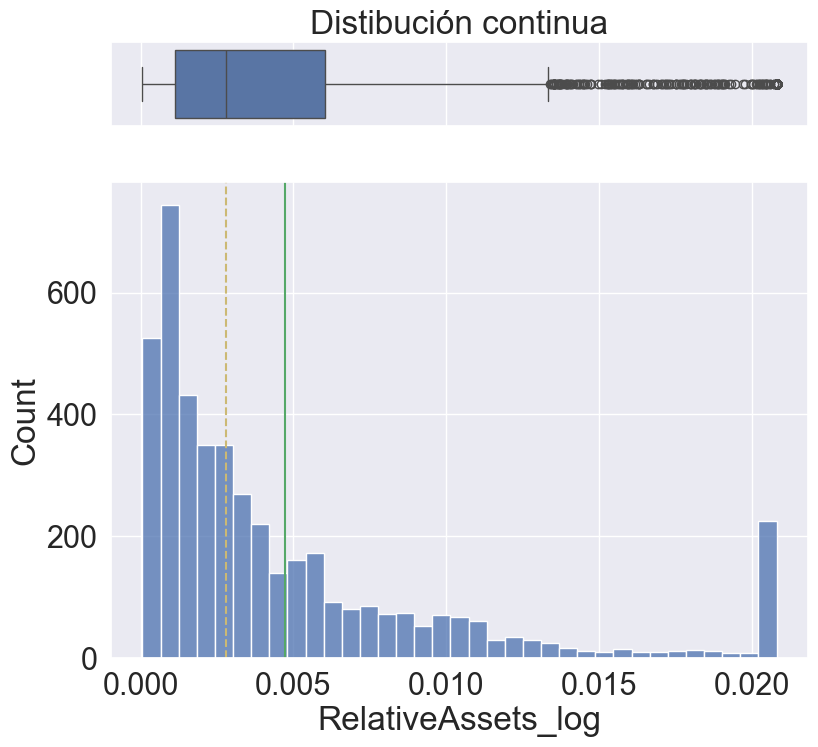

In [25]:
# Visualizar cambios
columna_a_graficar = 'RelativeAssets_log' # indicar columna para el grafico
plot(df_winsor[columna_a_graficar])

In [26]:
df_winsor.describe().T

,count,mean,std,min,25%,50%,75%,max
OperatingMargins,4486.0,0.193722,0.130622,-0.236850,0.126852,0.175926,0.247445,0.615838
ProfitMargins,4486.0,0.124435,0.122981,-0.281623,0.062082,0.089318,0.175560,0.516792
ReturnOnEquity,4486.0,0.198153,0.395604,-0.878453,0.072537,0.174397,0.387255,1.353706
ReturnOnAssets,4486.0,0.081920,0.083141,-0.277019,0.034350,0.067926,0.137481,0.447125
DebtToEquity,4486.0,0.881573,1.493979,-2.688342,0.366366,0.715545,1.381815,4.437273
Revenue_YoY,4486.0,0.303781,0.250537,-0.614272,0.121321,0.446584,0.446839,1.471254
Revenue_QoQ,4486.0,0.082011,0.107503,-0.306970,0.033506,0.063867,0.145584,0.489162
Ebitda_YoY,4486.0,0.373871,0.347691,-0.951324,0.154152,0.510780,0.510780,1.580676
Ebitda_QoQ,4486.0,0.117135,0.202526,-0.491645,0.031959,0.103692,0.201287,0.716929
Fcf_YoY,4486.0,0.192635,0.265904,-0.299324,0.116952,0.182288,0.255436,0.674598


## Concatenación final de columnas

In [27]:
df_non_numeric_transformed = df_transformed_features.select_dtypes(exclude='number')
# Se unen variables contínuas transformadas y variables no numéricas
df_combined = pd.concat([df_non_numeric_transformed, df_winsor], axis=1)

# Unir con las columnas que fueron salteadas
df_final = pd.concat([df_passthrough, df_combined], axis=1)
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4486 entries, 0 to 4485
Data columns (total 55 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   CashAndCashEquivalents  4486 non-null   float64       
 1   CurrentDebt             4486 non-null   float64       
 2   LongTermDebt            4486 non-null   float64       
 3   TotalDebt               4486 non-null   float64       
 4   StockholdersEquity      4486 non-null   float64       
 5   TotalAssets             4486 non-null   float64       
 6   CurrentAssets           4486 non-null   float64       
 7   CurrentLiabilities      4486 non-null   float64       
 8   OperatingCashFlow_TTM   4486 non-null   float64       
 9   InvestingCashFlow_TTM   4486 non-null   float64       
 10  FinancingCashFlow_TTM   4486 non-null   float64       
 11  FreeCashFlow_TTM        4486 non-null   float64       
 12  CapitalExpenditure_TTM  4486 non-null   float64 

In [28]:
# Guardar datos extraidos en fichero clean_data
df_final.to_parquet(f"{data_folder}/clean_data.parquet")